In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("placement.csv")

In [3]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [4]:
X = df.iloc[:,0].values
Y = df.iloc[:,1].values

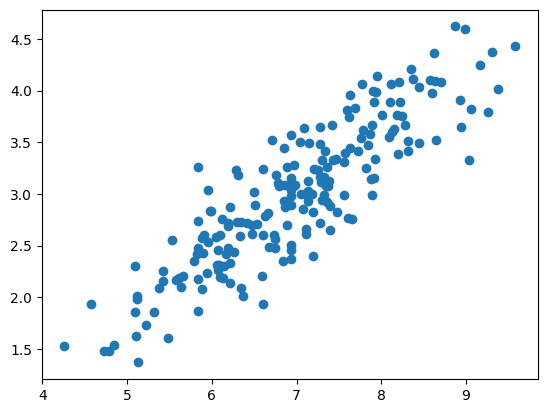

In [5]:
plt.scatter(X,Y)

In [6]:
# Linear Regression

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
lr = LinearRegression()

In [11]:
lr.fit(X_train.reshape(-1,1),Y_train)

LinearRegression()

In [12]:
print(lr.coef_,lr.intercept_)

[0.55795197] -0.8961119222429144


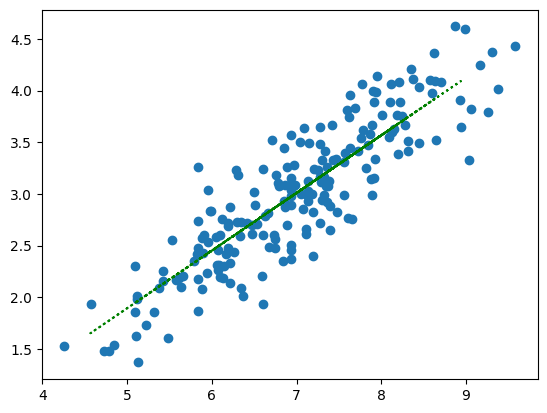

In [13]:
plt.scatter(X,Y)
plt.plot(X_test,lr.predict(X_test.reshape(-1,1)),ls='dotted',color='green')

In [14]:
from sklearn.metrics import r2_score

In [15]:
#Gradient Descent Class

In [39]:
class MyRegressior:

    #Constructor
    def __init__(self,epoch,lr_rate):
        self.m = 1
        self.b = -1
        self.lr = lr_rate
        self.epoch = epoch
        self.loss_array = []
        self.m_array = []
        self.b_array = []

    #Training
    def train(self,X_train,Y_train):
        for i in range(self.epoch):
            #Loss Function
            loss = np.sum((Y_train - self.m*X_train - self.b)*2)
            self.loss_array.append(loss)
            #Slope Calculation
            slope_m = -2*np.sum(np.dot((Y_train-self.m*X_train-self.b),X_train))
            slope_b = -2*np.sum((Y_train-self.m*X_train-self.b))
            #Weight update
            self.m = self.m - self.lr*slope_m
            self.m_array.append(self.m)
            self.b = self.b - self.lr*slope_b
            self.b_array.append(self.b)
        return(self.b,self.m)

    #Loss plot
    def loss_plot(self):
        fig1 = plt.plot(np.linspace(1,self.epoch,self.epoch),self.loss_array)
        return(fig1)

    #Loss Jump
    def loss_jump(self):
        fig1 = plt.scatter(np.linspace(1,self.epoch,self.epoch),self.loss_array,marker='.',color='red')
        return(fig1)

    def m_b_var(self):
        fig1 = plt.plot(np.linspace(1,self.epoch,self.epoch),self.m_array,color = 'red')
        fig2 = plt.plot(np.linspace(1,self.epoch,self.epoch),self.b_array,color = 'green')
        return(fig1,fig2)

    def test(self,X_test):
        y_pred = self.m*X_test + self.b
        return(y_pred)

    def plot(self,X_test,Y_test):
        plt.scatter(X_test,Y_test)
        plt.plot(X_test,lr.predict(X_test.reshape(-1,1)),ls='dotted',color='green')
        plt.plot(X_test,self.test(X_test),ls='dotted',color='red')
        r2_1 = r2_score(Y_test,lr.predict(X_test.reshape(-1,1)))
        r2_2 = r2_score(Y_test,self.test(X_test))
        print(f"r2_score from LinearRegression {r2_1} and r2_score from MyRegressor {r2_2}")
    

In [40]:
MyR = MyRegressior(30,0.00001)

In [41]:
MyR.train(X_train,Y_train)

(-1.0580261703872564, 0.5826474360409344)

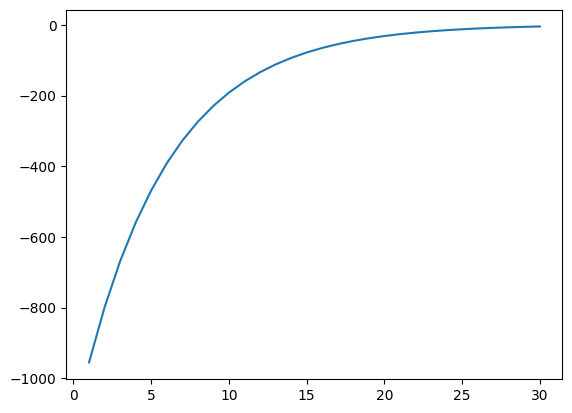

In [42]:
MyR.loss_plot()

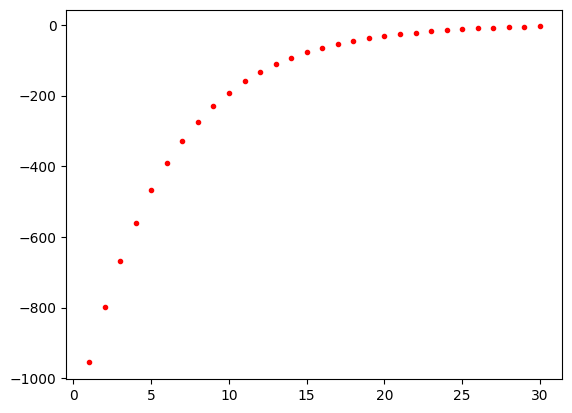

In [43]:
MyR.loss_jump()

([<matplotlib.lines.Line2D at 0x20415fb6850>],
 [<matplotlib.lines.Line2D at 0x20415fdd750>])

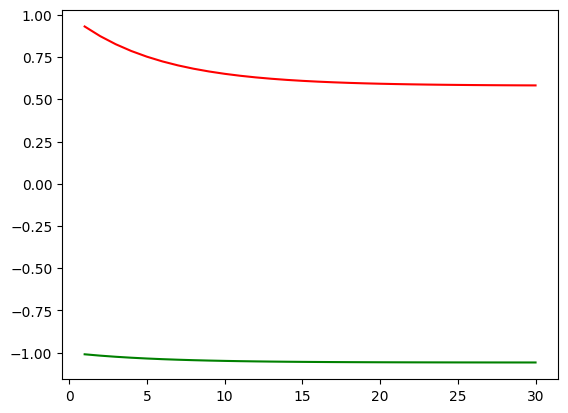

In [44]:
MyR.m_b_var()

r2_score from LinearRegression 0.780730147510384 and r2_score from MyRegressor 0.7835705361320502


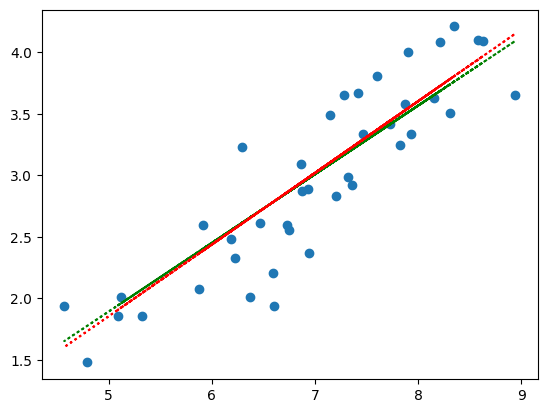

In [45]:
MyR.plot(X_test,Y_test)

In [1]:
#Batch GD

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_diabetes

In [3]:
X,Y = load_diabetes(return_X_y=True,as_frame=True)

In [7]:
X.shape

(442, 10)

In [9]:
X = X.values
Y = Y.values

AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [11]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=7)

In [12]:
#Through Linear Regression

In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
lr = LinearRegression()

In [15]:
lr.fit(X_train,Y_train)

LinearRegression()

In [18]:
r2 = r2_score(Y_test,lr.predict(X_test))
print(r2)

0.40430005635248034


In [20]:
print(lr.intercept_,lr.coef_)

153.96248367788561 [ -55.61758436 -259.84103752  540.30814766  344.62440892 -971.66791394
  612.39201814  155.14489732  190.63749388  830.74389027   73.87020866]


In [22]:
#Creating my own class

In [30]:
class MyBatchGD:
    #constructor
    def __init__(self,epoch,lr_rate):
        self.intercept = None
        self.coef = None
        self.epoch = epoch
        self.lr_rate = lr_rate
        self.loss_array = []

    #training
    def train(self,X_train,Y_train):
        self.intercept = 0 #beta_0
        self.coef = np.ones(X_train.shape[1]) #beta matrix -> Column
        for i in range(self.epoch):
            y_pred = np.dot(X_train,self.coef) + self.intercept
            #loss
            loss = np.mean((Y_train-y_pred)**2)
            self.loss_array.append(loss)
            #Intercept deri.
            intercept_der = (-2)*np.mean(Y_train-y_pred)
            #Intercept update
            self.intercept = self.intercept - self.lr_rate*intercept_der
            #coef deri.
            coef_der = (-2)*np.dot((Y_train-y_pred),X_train)
            #coef update
            self.coef = self.coef - self.lr_rate*coef_der
        return(self.intercept,self.coef)

    #testing
    def test(self,X_test,Y_test):
        y_pred = np.dot(X_test,self.coef) + self.intercept
        r2 = r2_score(Y_test,y_pred)
        return(r2)

    #loss plot
    def loss_plot(self):
        plt.plot(np.linspace(1,self.epoch,self.epoch),self.loss_array,color = 'green')

In [31]:
BGD = MyBatchGD(100,0.1)

In [32]:
BGD.train(X_train,Y_train)

(153.99214441600486,
 array([ -57.94699803, -255.01289047,  550.57458685,  338.1943773 ,
        -153.9845104 ,  -48.55776059, -190.11934059,  114.49960296,
         528.38445189,   73.53862515]))

In [33]:
BGD.test(X_test,Y_test)

0.40862409871679284

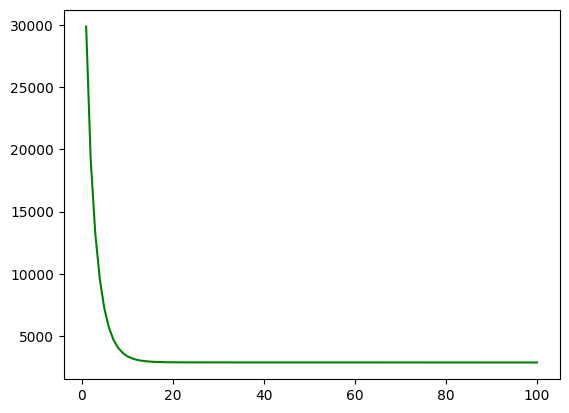

In [34]:
BGD.loss_plot()

In [35]:
#Stochastic GD

In [63]:
class MySchochasticGD:
    #constructor
    def __init__(self,epoch,lr_rate):
        self.intercept = None
        self.coef = None
        self.epoch = epoch
        self.lr_rate = lr_rate
        self.loss_array = []

    #training
    def train(self,X_train,Y_train):
        self.intercept = 0 #beta_0
        self.coef = np.ones(X_train.shape[1]) #beta matrix -> Column
        for i in range(self.epoch):
            loss_per_row = []
            for j in range(X_train.shape[0]):
                idx = np.random.randint(0,X_train.shape[0])
                y_pred = np.dot(X_train[idx],self.coef) + self.intercept
                #Calculate loss
                loss = np.mean((Y_train[idx]-y_pred)**2)
                loss_per_row.append(loss)
                #Intercept deri.
                intercept_der = (-2)*np.mean(Y_train[idx]-y_pred)
                #Intercept update
                self.intercept = self.intercept - self.lr_rate*intercept_der
                #coef deri.
                coef_der = (-2)*np.dot((Y_train[idx]-y_pred),X_train[idx])
                #coef update
                self.coef = self.coef - self.lr_rate*coef_der
            loss = np.mean(loss_per_row)
            self.loss_array.append(loss)
            loss = 0
        return(self.intercept,self.coef)
                    
    #testing
    def test(self,X_test,Y_test):
        y_pred = np.dot(X_test,self.coef) + self.intercept
        r2 = r2_score(Y_test,y_pred)
        return(r2)

    #loss plot
    def loss_plot(self):
        plt.plot(np.linspace(1,self.epoch,self.epoch),self.loss_array,color = 'green')

In [64]:
idx = np.random.randint(0,100)
print(idx)
X_train[idx]

78


array([-0.00188202, -0.04464164, -0.06979687, -0.01255612, -0.00019301,
       -0.00914259,  0.07072993, -0.03949338, -0.06291688,  0.04034337])

In [65]:
SGD = MySchochasticGD(100,0.06)

In [66]:
SGD.train(X_train,Y_train)

(148.72697441015956,
 array([ -48.33546398, -238.38763792,  547.24894718,  351.2797507 ,
        -120.42745491,  -87.88918634, -229.26678955,  104.14260932,
         497.75227658,   88.88066603]))

In [67]:
SGD.test(X_test,Y_test)

0.42293394241417703

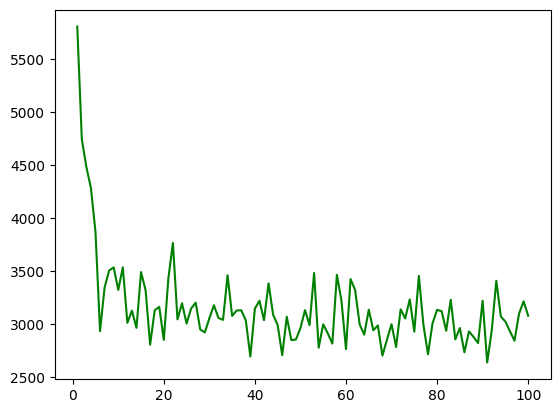

In [68]:
SGD.loss_plot()

In [69]:
#From sklearn

In [70]:
from sklearn.linear_model import SGDRegressor

In [78]:
SGDR = SGDRegressor(max_iter=1000,learning_rate='constant',eta0=0.06,early_stopping=True)

In [81]:
SGDR.fit(X_train,Y_train)

SGDRegressor(early_stopping=True, eta0=0.06, learning_rate='constant')

In [82]:
r2 = r2_score(Y_test,SGDR.predict(X_test))
print(r2)

0.4448594176372208
